# Exploration et Nettoyage des Données Adzuna
Ce notebook permet d'analyser le résultat de l'ingestion brute depuis l'API Adzuna et d'explorer les données de la même manière que pour Arbeitnow.

In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from scripts.ingestion.adzuna_client import collect_adzuna, filter_new_jobs
from datetime import datetime, timedelta

raw_jobs = collect_adzuna(max_days_old=5)

last_run = (datetime.now() - timedelta(hours=48)).strftime('%Y-%m-%dT%H:%M:%SZ')
new_jobs = filter_new_jobs(raw_jobs, last_run)

print(f"Total jobs: {len(raw_jobs)}")
print(f"New jobs since last run: {len(new_jobs)}")

2026-04-16 15:41:25,293 | INFO | adzuna_client | Adzuna ingestion started
2026-04-16 15:41:25,295 | INFO | adzuna_client | Fetching Adzuna page 1
2026-04-16 15:41:48,441 | INFO | adzuna_client | Fetching Adzuna page 2
2026-04-16 15:41:54,989 | INFO | adzuna_client | Fetching Adzuna page 3
2026-04-16 15:42:04,922 | INFO | adzuna_client | Fetching Adzuna page 4
2026-04-16 15:42:11,986 | INFO | adzuna_client | Fetching Adzuna page 5
2026-04-16 15:42:19,370 | INFO | adzuna_client | Fetching Adzuna page 6
2026-04-16 15:42:35,136 | INFO | adzuna_client | Fetching Adzuna page 7
2026-04-16 15:42:46,067 | INFO | adzuna_client | Fetching Adzuna page 8
2026-04-16 15:42:56,735 | INFO | adzuna_client | Fetching Adzuna page 9
2026-04-16 15:43:04,276 | INFO | adzuna_client | Fetching Adzuna page 10
2026-04-16 15:43:16,704 | INFO | adzuna_client | Fetching Adzuna page 11
2026-04-16 15:43:29,303 | INFO | adzuna_client | Fetching Adzuna page 12
2026-04-16 15:43:42,141 | INFO | adzuna_client | Fetching A

In [2]:
import pandas as pd
df = pd.DataFrame(raw_jobs)
df.head()

,job_id,job_title,company_name,job_description,tags,location,salary_min,salary_max,posted_date,expires_date,contract_type,currency,remote,job_url,source_site
0,5700647536,Data Engineer - Aeroline - Aix-en-Provence,Sopra Steria,"Description de l'entreprise Sopra Steria , act...",Unknown,"Aix-en-Provence, Bouches-du-Rhône",NaN,NaN,2026-04-15T23:37:28Z,None,None,None,None,https://www.adzuna.fr/land/ad/5700647536?se=Sr...,Adzuna
1,5699374652,Data Engineer senior - Services Financiers - L...,Sopra Steria,"Description de l'entreprise Sopra Steria , act...",Unknown,"Villeneuve-d'Ascq, Lille",NaN,NaN,2026-04-14T23:25:33Z,None,None,None,None,https://www.adzuna.fr/land/ad/5699374652?se=Sr...,Adzuna
2,5699959446,Data analyst h/f (CDI),Mercato de l'emploi,OFFRE – DATA ANALYST (H/F) CDI cadre – Bordeau...,Unknown,"Gironde, Nouvelle-Aquitaine",NaN,NaN,2026-04-15T11:15:54Z,None,permanent,None,None,https://www.adzuna.fr/land/ad/5699959446?se=Sr...,Adzuna
3,5699959420,Data analyst h/f (CDI),Mercato de l'emploi,OFFRE – DATA ANALYST (H/F) CDI cadre – Niort Q...,Unknown,"Deux-Sèvres, Nouvelle-Aquitaine",NaN,NaN,2026-04-15T11:15:54Z,None,permanent,None,None,https://www.adzuna.fr/land/ad/5699959420?se=Sr...,Adzuna
4,5699959450,Data engineer h/f (CDI),Mercato de l'emploi,DATA ANALYST CONFIRMÉ (H/F) CDI cadre – NIORT ...,Unknown,"Deux-Sèvres, Nouvelle-Aquitaine",NaN,NaN,2026-04-15T11:15:54Z,None,permanent,None,None,https://www.adzuna.fr/land/ad/5699959450?se=Sr...,Adzuna


In [3]:
df.isnull().sum()

job_id                0
job_title             0
company_name         13
job_description       0
tags                  0
location              0
salary_min         1700
salary_max         1700
posted_date           0
expires_date       2350
contract_type       938
currency           2350
remote             2350
job_url               0
source_site           0
dtype: int64

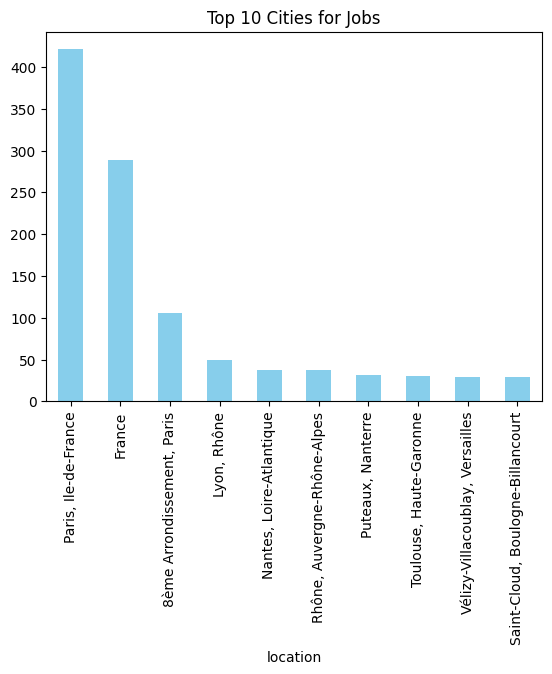

In [4]:
import matplotlib.pyplot as plt

# Chart of the top 10 cities with the most jobs
df['location'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Cities for Jobs')
plt.show()

In [5]:
df.head(1)

,job_id,job_title,company_name,job_description,tags,location,salary_min,salary_max,posted_date,expires_date,contract_type,currency,remote,job_url,source_site
0,5700647536,Data Engineer - Aeroline - Aix-en-Provence,Sopra Steria,"Description de l'entreprise Sopra Steria , act...",Unknown,"Aix-en-Provence, Bouches-du-Rhône",NaN,NaN,2026-04-15T23:37:28Z,None,None,None,None,https://www.adzuna.fr/land/ad/5700647536?se=Sr...,Adzuna


In [6]:
print("Top 5 Tags/Categories:")
print(df['tags'].value_counts().head(5))

Top 5 Tags/Categories:
tags
Unknown                   1199
Emplois Informatique       358
Emplois Autres/Général     197
Emplois Consultants        119
Emplois Ingénierie          77
Name: count, dtype: int64


In [7]:
print(f"Duplicates: {df.duplicated(subset=['job_id']).sum()}")

Duplicates: 0


In [8]:
print(df.isnull().sum())

job_id                0
job_title             0
company_name         13
job_description       0
tags                  0
location              0
salary_min         1700
salary_max         1700
posted_date           0
expires_date       2350
contract_type       938
currency           2350
remote             2350
job_url               0
source_site           0
dtype: int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2350 entries, 0 to 2349
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_id           2350 non-null   object 
 1   job_title        2350 non-null   object 
 2   company_name     2337 non-null   object 
 3   job_description  2350 non-null   object 
 4   tags             2350 non-null   object 
 5   location         2350 non-null   object 
 6   salary_min       650 non-null    float64
 7   salary_max       650 non-null    float64
 8   posted_date      2350 non-null   object 
 9   expires_date     0 non-null      object 
 10  contract_type    1412 non-null   object 
 11  currency         0 non-null      object 
 12  remote           0 non-null      object 
 13  job_url          2350 non-null   object 
 14  source_site      2350 non-null   object 
dtypes: float64(2), object(13)
memory usage: 275.5+ KB


## job_description Column

In [10]:
df['job_description']

0       Description de l'entreprise Sopra Steria , act...
1       Description de l'entreprise Sopra Steria , act...
2       OFFRE – DATA ANALYST (H/F) CDI cadre – Bordeau...
3       OFFRE – DATA ANALYST (H/F) CDI cadre – Niort Q...
4       DATA ANALYST CONFIRMÉ (H/F) CDI cadre – NIORT ...
                              ...                        
2345    En tant que développeur, vous rejoindrez l'équ...
2346    Votre quotidien Le site de Cannes est en charg...
2347    CONTEXTE Cette équipe qui est transverse adres...
2348    Je suis Antony Laplagne, Consultant au sein de...
2349     Release Train Engineer (RTE) – Projets IT Tra...
Name: job_description, Length: 2350, dtype: object

In [11]:
# Detecting the presence of HTML tags
html_rows = df[df['job_description'].str.contains(r'<.*?>', na=False)]

print("Rows containing HTML:")
print(html_rows[['job_description']].head())

Rows containing HTML:
Empty DataFrame
Columns: [job_description]
Index: []


#### Problem

The extracted text contains HTML tags like `<h2>`, `<li>`, and `<p>` instead of clean text.  
This makes the content hard to read and mixes data with presentation.  
It also complicates searching and extracting useful information like skills (e.g., "Python").  
We need plain text to store and process data efficiently.

## posted_date Column

In [12]:
print(df.dtypes)

job_id              object
job_title           object
company_name        object
job_description     object
tags                object
location            object
salary_min         float64
salary_max         float64
posted_date         object
expires_date        object
contract_type       object
currency            object
remote              object
job_url             object
source_site         object
dtype: object


In [13]:
df["posted_date"]

0       2026-04-15T23:37:28Z
1       2026-04-14T23:25:33Z
2       2026-04-15T11:15:54Z
3       2026-04-15T11:15:54Z
4       2026-04-15T11:15:54Z
                ...         
2345    2026-04-16T01:30:56Z
2346    2026-04-16T04:11:01Z
2347    2026-04-16T08:16:48Z
2348    2026-04-15T10:21:30Z
2349    2026-04-16T06:05:37Z
Name: posted_date, Length: 2350, dtype: object

In [14]:
# Invalid or missing values
invalid_created = df[df['posted_date'].isnull()]

print("Invalid posted_date values:")
print(invalid_created[['posted_date']].head())

Invalid posted_date values:
Empty DataFrame
Columns: [posted_date]
Index: []


#### Dataset Note

The `posted_date` field is stored as an ISO string format for Adzuna.  
It should be human-readable, but might need formatting to YYYY-MM-DD for easier querying or filtering.

## tags Column

In [15]:
df['tags']

0                               Unknown
1                               Unknown
2                               Unknown
3                               Unknown
4                               Unknown
                     ...               
2345                            Unknown
2346             Emplois Autres/Général
2347               Emplois Informatique
2348    Emplois Comptabilité et Finance
2349                            Unknown
Name: tags, Length: 2350, dtype: object

#### Tags Column

Here, tags reflect the Adzuna Category. Often this is just a single string instead of a list of keywords like with Arbeitnow.

## location column

In [16]:
# 1. Discovering values with extra spaces
spaces_issues = df[df['location'].notna() & (df['location'] != df['location'].str.strip())]

print("Rows with extra spaces:")
print(spaces_issues['location'].head(), "\n")

Rows with extra spaces:
784      Gémenos, La Ciotat
1508     Gémenos, La Ciotat
1578     Gémenos, La Ciotat
Name: location, dtype: object 



In [17]:
# 2. Discovering values that are not in a standard format (title case)
case_issues = df[df['location'].notna() & (df['location'] != df['location'].str.title())]

print("Rows with inconsistent casing:")
print(case_issues['location'].head(), "\n")

Rows with inconsistent casing:
0    Aix-en-Provence, Bouches-du-Rhône
1             Villeneuve-d'Ascq, Lille
6              Yvelines, Ile-de-France
7          12ème Arrondissement, Paris
8                 Paris, Ile-de-France
Name: location, dtype: object 

